**_#1.字母异位词分组_**

In [ ]:
class Solution(object):
    def groupAnagrams(self, strs):
        """
        :type strs: List[str]
        :rtype: List[List[str]]
        """
        dict={}
        for char in strs:
            goal =''.join(sorted(char))
            if goal not in dict:
                dict[goal]=[]
            dict[goal].append(char)
        return list(dict.values())


if goal not in dict 与 if goal not in dict.keys()在性能上有较大区别，dict.keys()先生成一个字典键的列表，然后在这个列表里线性查找，时间复杂度为o(n),而in dict方法基于哈希表进行查找，时间复杂度为O（1）

此外，对于字符串而言，应使用sorted()方法进行排序，排序后返回的结果是一个字符列表，使用‘’.join（）后可变为一个字符串。.sort是针对列表的排序方法。

字典是一种典型的哈希表，字典的一些操作总结：
字典的键要求是不可变对象，因此列表，集合不满足要求而元组可以

        dict.keys():返回一个字典的键的视图对象，而不是列表，使用list（）可将其列表化
        dict.values():返回一个字典的值的视图对象，而不是列表，使用list（）可将其列表化
        if i in dict:判断一个字典中是否有对应的键
        for i in dict:遍历字典的键
        for key, value in my_dict.items():遍历键值对

sorted()是Python内置函数，它可以对任何可迭代对象进行排序，并返回一个新的排序后的列表，原可迭代对象保持不变。

sort()是列表对象的一个方法，它会直接修改原列表，将其排序，并且不返回任何值（返回None）。

#2.移动0问题

In [ ]:
class Solution(object):
    def moveZeroes(self, nums):
        """
        :type nums: List[int]
        :rtype: None Do not return anything, modify nums in-place instead.
        """
        length1 = len(nums)
        for i in range(length1):
            num =nums.pop(0)
            if num:
                nums.append(num)
        length2 = len(nums)
        nums.extend([0] * (length1 - length2))
        return nums

列表的相加可以使用：

        1.nums+=[0]*length
        2.nums.extend([0]*length)

**_#3.链表反转问题：_**

**_#4.相同节点问题：_**

#使用集合而非列表存储节点，因为在后续的环节，使用列表的话时间复杂度为0(n),而对于集合而言，时间复杂度为0(1),**_对于集合与字典而言，哪怕是值与后继都相同的两个节点，地址不同的话仍然可以存放进去。_**

        if right in list1:


同样的道理，对于下面展示的节点数据结构，在使用的时候，是根据这两个节点的地址是否相同来判断的！！！

        node1==node2
        for (if) in list1

集合添加元素的语句为

        set.add()

In [ ]:
class Solution(object):
    def getIntersectionNode(self, headA, headB):
        """
        :type head1, head1: ListNode
        :rtype: ListNode
        """
        list1 = set()
        left = headA
        right = headB
        while left:
            list1.add(left)
            left =left.next
        while right:
            if right in list1:
                return right
            right = right.next
        return None


**_#5.环形链表问题：_**

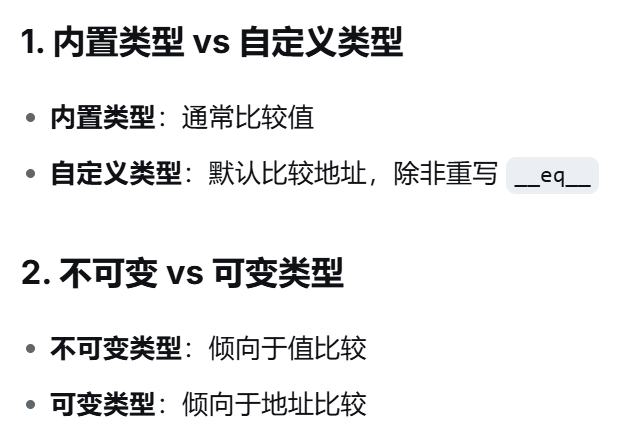

佛洛依德判圈算法：使用快慢指针检测是否存在环，快指针每次走两步，慢指针每次走一步，如果最终快指针追上慢指针，证明有环。

In [ ]:
# Definition for singly-linked list.
# class ListNode(object):
#     def __init__(self, x):
#         self.val = x
#         self.next = None

class Solution(object):
    def hasCycle(self, head):
        """
        :type head: ListNode
        :rtype: bool
        """
        if not head or not head.next:
            return False
        slow = head
        fast = head
        while slow != fast:
            if not fast.next or not fast.next.next:
                return False
            slow = slow.next
            fast = fast.next.next
        return True

**_环形链表问题II（返回入环的第一个节点）_**

原理分析：

        快指针走过的距离应该是a+b+n(b+c)

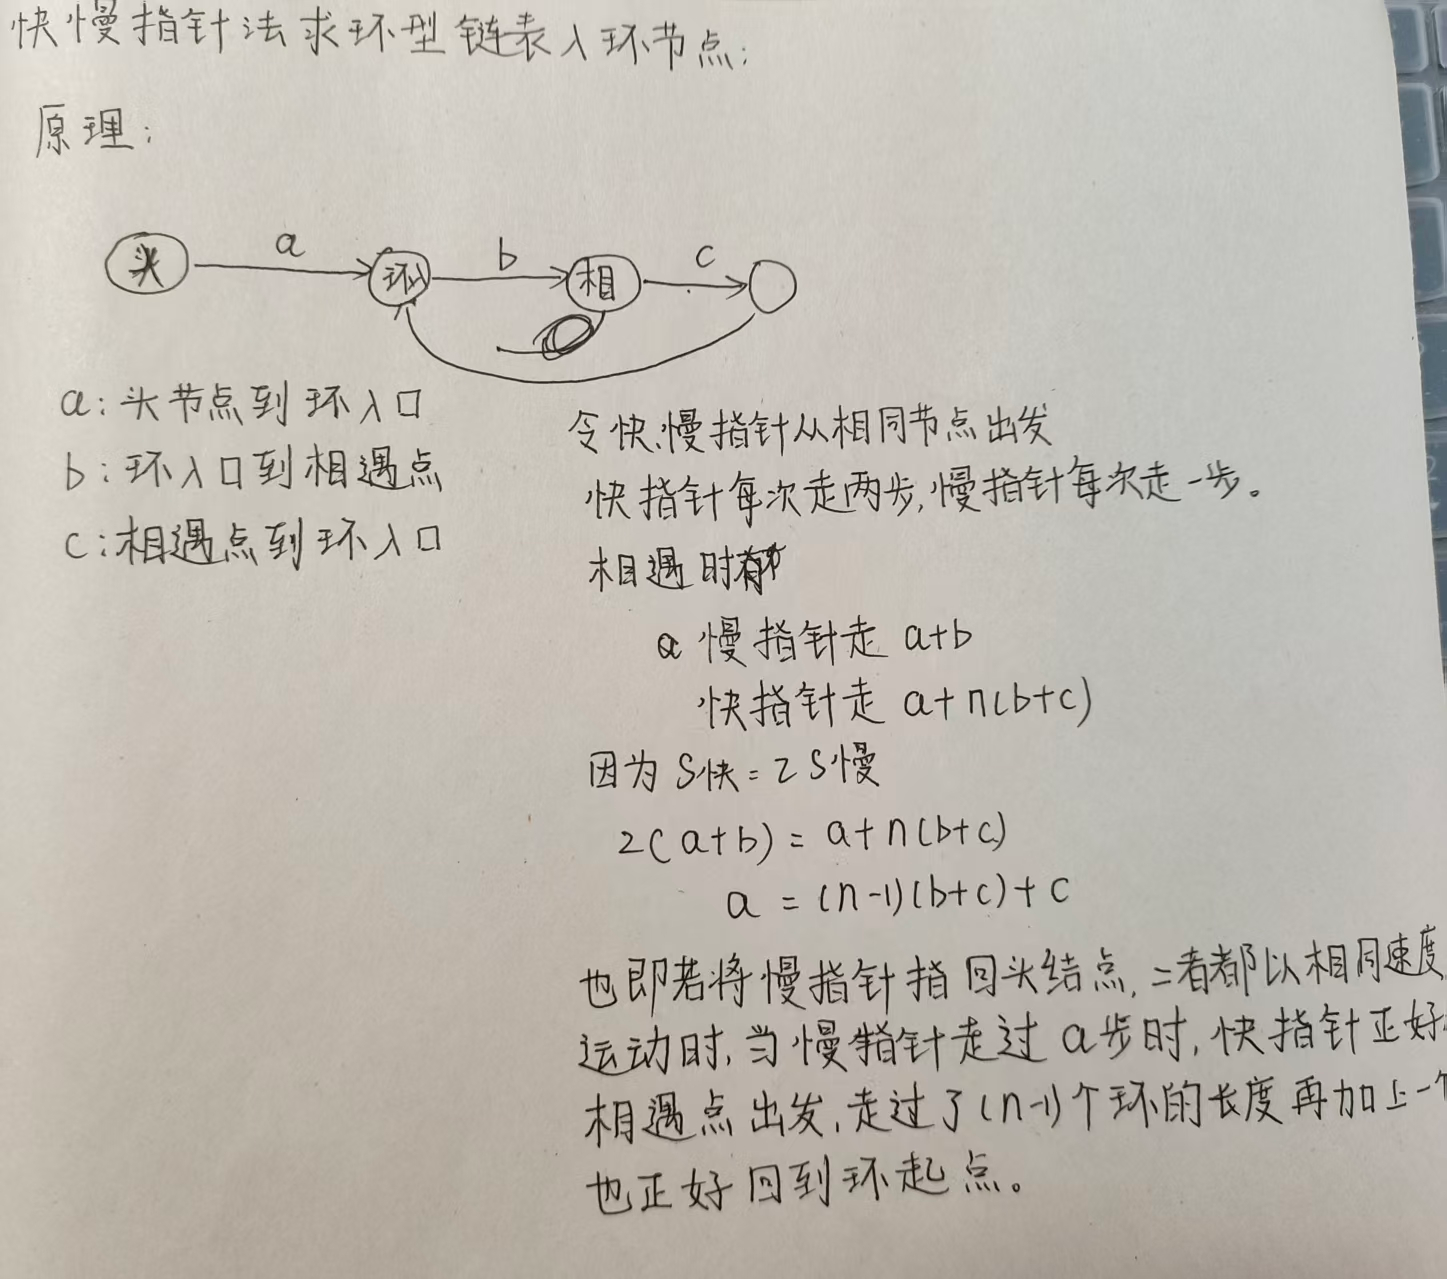



In [ ]:
class Solution(object):
    def detectCycle(self, head):
        if not head or not head.next:
            return None
        fast = head
        slow = head
        while fast.next and fast.next.next:#可以改为while fast and fast.next
            fast = fast.next.next
            slow = slow.next
            if fast == slow:
                slow = head
                while slow != fast:
                    slow = slow.next
                    fast = fast.next
                return fast
        return None

**_#6.回文链表问题_**

回文链表问题使用快慢指针方法解答最优，其中，慢指针每次走一步，快指针每次走两步。

In [ ]:
# Definition for singly-linked list.
# class ListNode(object):
#     def __init__(self, val=0, next=None):
#         self.val = val
#         self.next = next
class Solution(object):
    def isPalindrome(self, head):
        """
        :type head: Optional[ListNode]
        :rtype: bool
        """
        fast = head
        slow = head
        start = head

        #找中算法------------------------------------------------
        while fast and fast.next:#这种情况下慢指针最终会指向中间元素（奇数个）或者中间元素的第二个（偶数情况下），使用反转链表的方法对从slow开始的链表进行处理。若是奇数个，链表的两部分仍连在一起，偶数个的时候，右边比左边少一个。

            #当使用 while fast.next and fast.next.next:时，对于偶数情况而言，返回的是中间元素的第一个。
            slow = slow.next
            fast = fast.next.next
        #-------------------------------------------------------

        #链表反转算法---------------------------------------------
        pre = None
        curr = slow
        while curr:
            temp = curr.next
            curr.next = pre
            pre = curr
            curr = temp
        #-------------------------------------------------------
        while pre:
            if pre.val != start.val:
                return False
            pre = pre.next
            start = start.next
        return True


**_7.两两交换相邻的节点_**

**_#8.链表的排序问题_**

对于链表头指针head而言，如果利用其他指针对节点进行了修改，再利用head访问的也是修改后的节点（后继与值发生变化）

采用归并排序方法，首先寻找链表的中间节点，将链表按照中间节点分为两部分（注意要将中间节点的next属性设置为null，然后将两部分分别递归，注意使用哑节点。

In [ ]:
# Definition for singly-linked list.
class ListNode(object):
    def __init__(self, val=0, next=None):
        self.val = val
        self.next = next
class Solution(object):
    def sortList(self, head):
        """
        :type head: Optional[ListNode]
        :rtype: Optional[ListNode]
        """
        dummy = ListNode(0)
        original = dummy
        dummy.next = head
        fast = head
        slow = head
        if not head or not head.next:#基本结束条件
            return head

        while fast.next and fast.next.next:
            slow = slow.next
            fast = fast.next.next
        temp = slow.next
        slow.next = None
        left = self.sortList(head)
        right = self.sortList(temp)

        while left and right:
            if left.val > right.val:
                dummy.next = right
                right = right.next
            else:
                dummy.next = left
                left = left.next
            dummy = dummy.next
        dummy.next = left if left else right

        return original.next

**_#9.合并k个升序链表_**

此题的思路与链表的归并排序以及两个链表的合并有关，思想是先对链表数组进行递归拆分，然后将单个链表返回并对返回的链表采用链表的合并策略，总体而言相较于链表的直接归并排序要简单一些，因为不需要自己手动将链表拆解。

In [ ]:
class Solution(object):
    def mergeKLists(self, lists):
        """
        :type lists: List[Optional[ListNode]]
        :rtype: Optional[ListNode]
        """
        def sort(lists,left,right):
            if left > right:#这种情况发生在传入列表为空的情况下
                return []
            elif left == right:
                return lists[left]
            else:#归并排序的算法思想
                dummy = ListNode(0)
                orig = dummy
                mid = (left+right)//2
                left = sort(list,left,mid)
                right = sort(list,mid+1,right)
                while left and right:#链表的合并
                    if left.val < right.val:
                        left = left.next
                        dummy.next = left
                    else:
                        right = right.next
                        dummy.next = right
                    dummy = dummy.next
                dummy.next = left if left else right
                return orig.next

**_#12.k个一组反转链表_**

此题的主要思想是递归，可以将链表分解为待处理的右边和已经处理完的左边。

In [ ]:
class Solution(object):
    def reverseKGroup(self, head, k):

        def reverse(node):
            pre = None
            curr = node
            while curr:
                temp = curr.next
                curr.next = pre
                pre = curr
                curr = temp
            return pre

        dummy = ListNode(0)
        dummy.next = head
        pre = dummy

        while True:
            end = pre
            for _ in range(k):
                end = end.next#先进行移动在判断，因为end最开始指向的是上一组的最后一个元素，而我要判断的是当前的这一组元素是否有k个
                if not end:
                    return dummy.next#不够k个时直接返回结果就行，因为当前的这些节点已经和之前反转的节点连接在一起了

            new_group = end.next
            end.next = None

            start = pre.next
            new_head = reverse(start)#new_head为反转后的首端

            pre.next = new_head
            start.next = new_group#start.next为反转后的尾端

            pre = start

**_#13.随机链表的复制_**

想要完成链表的深拷贝要求先创建所有的节点，在进行next与random的设置，使用哈希表构建原节点与新节点的映射，在构建新节点的next与random。

In [ ]:
class Node:
    def __init__(self, x, next=None, random=None):
        self.val = int(x)
        self.next = next
        self.random = random

class Solution(object):
    def copyRandomList(self, head):

        if not head:
            return None

        mapping = {}   # old -> new

        # 第 1 步：复制所有节点（只复制 val）
        cur = head
        while cur:
            mapping[cur] = Node(cur.val)
            cur = cur.next

        # 第 2 步：复制 random 和 next
        cur = head
        while cur:
            mapping[cur].next = mapping.get(cur.next)#如果找不到返回None
            mapping[cur].random = mapping.get(cur.random)
            cur = cur.next

        # 返回新链表的头节点
        return mapping[head]